##  Import Libraries and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Text processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics # Renamed to avoid conflict with functions like precision_score

# Visualization
!pip install wordcloud -qq  # Install wordcloud quietly
from wordcloud import WordCloud
from scipy.stats import mode

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(" All libraries imported successfully!")

 All libraries imported successfully!


## Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


print("Loading datasets...")

df_true = pd.read_csv("/content/drive/MyDrive/ML dataset/True.csv", engine="python", on_bad_lines="skip")
df_fake = pd.read_csv("/content/drive/MyDrive/ML dataset/Fake.csv", engine="python", on_bad_lines="skip")

print(f" True news articles: {len(df_true)}")
print(f" Fake news articles: {len(df_fake)}")
print(f" Total articles: {len(df_true) + len(df_fake)}")


Loading datasets...
 True news articles: 21417
 Fake news articles: 23481
 Total articles: 44898


##  Data Preparation & Initial Setup

In [ ]:
# Add class labels
df_fake["class"] = 0  # Fake news
df_true["class"] = 1  # True news

# Create manual testing sets (last 10 from each)
df_fake_manual = df_fake.tail(10).copy()
df_true_manual = df_true.tail(10).copy()

# Remove manual testing data from main datasets
df_fake = df_fake.iloc[:-10]
df_true = df_true.iloc[:-10]

print(f"After removing test data:")
print(f"Fake news for training: {len(df_fake)}")
print(f"True news for training: {len(df_true)}")

# Combine datasets
df = pd.concat([df_fake, df_true], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Remove unnecessary columns
df = df.drop(["title", "subject", "date"], axis=1)

# Create manual testing set
df_manual_test = pd.concat([df_fake_manual, df_true_manual], axis=0)
df_manual_test = df_manual_test.drop(["title", "subject", "date"], axis=1)

print(f"\n Final training dataset shape: {df.shape}")
print(f" Manual test dataset shape: {df_manual_test.shape}")
print(f" Data preprocessing complete!")

After removing test data:
Fake news for training: 23471
True news for training: 21407

 Final training dataset shape: (44878, 2)
 Manual test dataset shape: (20, 2)
 Data preprocessing complete!


###  NLTK Setup & Downloads

In [ ]:
# Download all required NLTK data
nltk_downloads = [
    'stopwords', 'punkt', 'wordnet', 'omw-1.4',
    'averaged_perceptron_tagger', 'punkt_tab'
]

for resource in nltk_downloads:
    try:
        nltk.download(resource, quiet=True)
    except:
        print(f"Could not download {resource}")

print(" NLTK resources downloaded successfully!")

 NLTK resources downloaded successfully!


##  Advanced Text Preprocessing with WordNet Lemmatization

In [ ]:
# =====================================================
# ADVANCED TEXT PREPROCESSING WITH WORDNET LEMMATIZATION
# =====================================================

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# -----------------------------------------------------
#  Ensure all required NLTK resources are available
# -----------------------------------------------------
resources = [
    'stopwords',
    'punkt',
    'punkt_tab',
    'wordnet',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng'
]
for r in resources:
    try:
        if "punkt" in r:
            nltk.data.find(f"tokenizers/{r}")
        elif "tagger" in r:
            nltk.data.find(f"taggers/{r}")
        else:
            nltk.data.find(f"corpora/{r}")
    except LookupError:
        nltk.download(r)

# -----------------------------------------------------
# Initialize lemmatizer and stopword list
# -----------------------------------------------------
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# -----------------------------------------------------
# Helper function: Map POS tags to WordNet format
# -----------------------------------------------------
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

# -----------------------------------------------------
# Advanced preprocessing with POS-based lemmatization
# -----------------------------------------------------
def advanced_text_preprocessing(text):
    """Cleans, tokenizes, removes stopwords, and lemmatizes text"""
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove HTML tags, URLs, and unwanted chars
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    # Remove punctuation and numbers
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)

    # Tokenize
    words = word_tokenize(text)

    # Lemmatize with POS tagging
    processed_words = []
    for word in words:
        if word not in stop_words and len(word) > 2:
            pos = get_wordnet_pos(word)
            lemmatized_word = lemmatizer.lemmatize(word, pos)
            processed_words.append(lemmatized_word)

    return ' '.join(processed_words)

# -----------------------------------------------------
# Apply preprocessing to datasets
# -----------------------------------------------------
print(" Preprocessing training data...")
df["text"] = df["text"].astype(str).apply(advanced_text_preprocessing)

if "df_manual_test" in globals():
    print(" Preprocessing manual test data...")
    df_manual_test["text"] = df_manual_test["text"].astype(str).apply(advanced_text_preprocessing)

print(" Text preprocessing completed with WordNet lemmatization!")



[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


 Preprocessing training data...
 Preprocessing manual test data...
 Text preprocessing completed with WordNet lemmatization!


##  Exploratory Data Analysis (EDA)

In [ ]:
# Basic statistics
print(" Dataset Overview:")
print(f"Total articles: {len(df)}")
print(f"Fake news: {len(df[df['class'] == 0])} ({len(df[df['class'] == 0])/len(df)*100:.1f}%)")
print(f"True news: {len(df[df['class'] == 1])} ({len(df[df['class'] == 1])/len(df)*100:.1f}%)")

# Text length analysis
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("\ Text Statistics:")
print(f"Average text length: {df['text_length'].mean():.0f} characters")
print(f"Average word count: {df['word_count'].mean():.0f} words")
print(f"Max text length: {df['text_length'].max()} characters")
print(f"Min text length: {df['text_length'].min()} characters")

 Dataset Overview:
Total articles: 44878
Fake news: 23471 (52.3%)
True news: 21407 (47.7%)
\ Text Statistics:
Average text length: 1625 characters
Average word count: 224 words
Max text length: 37037 characters
Min text length: 0 characters


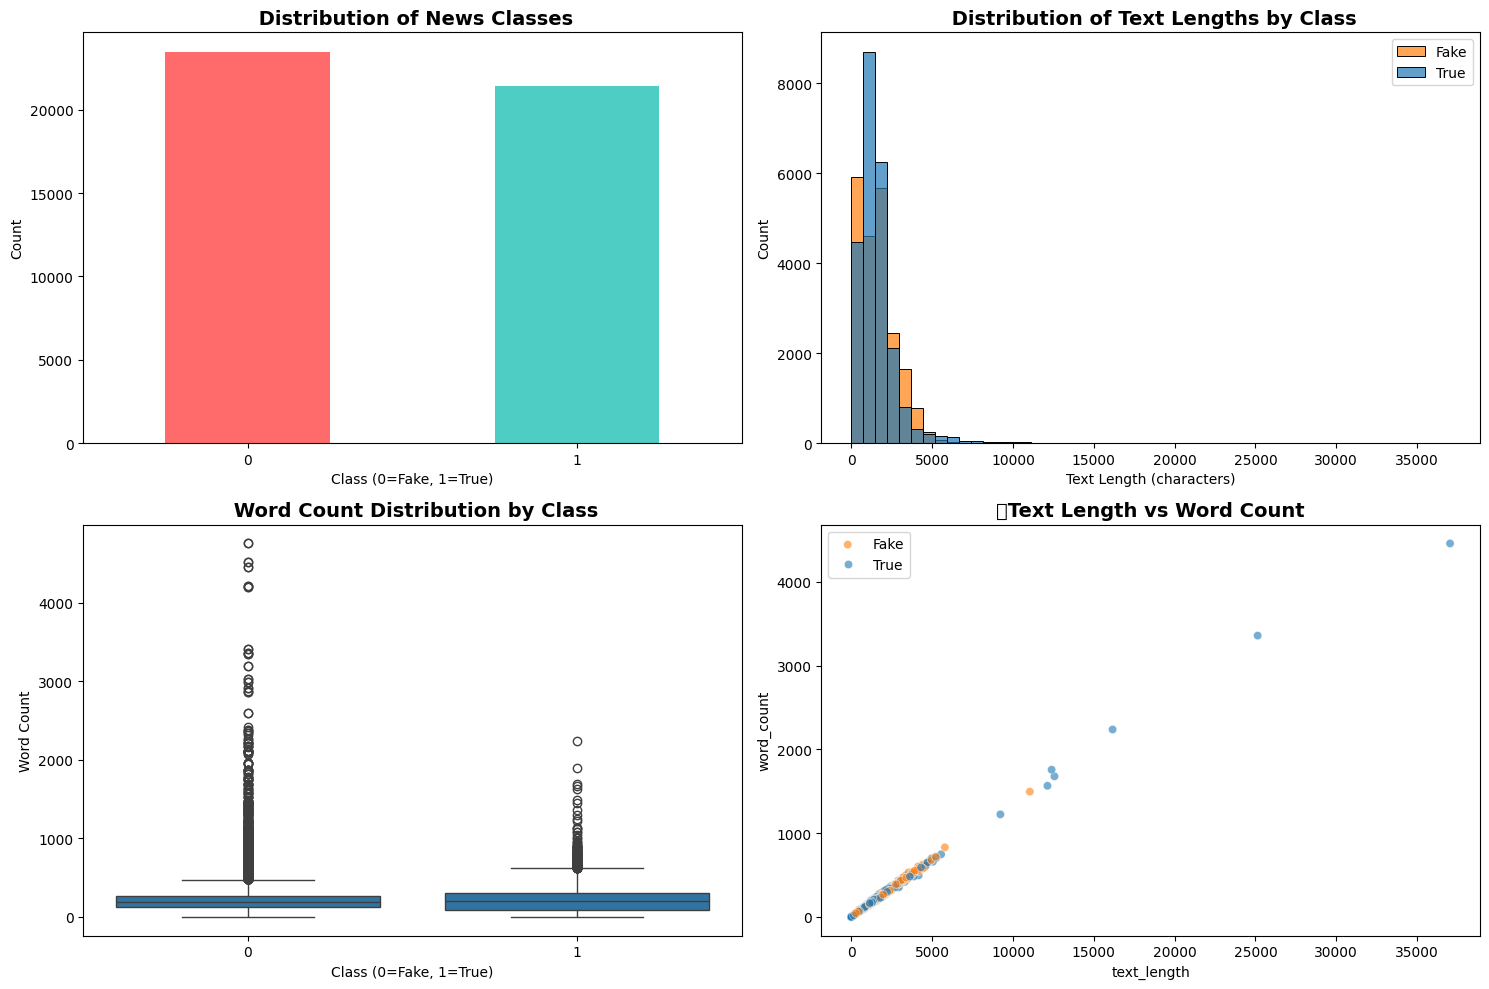

 EDA visualizations completed!


In [ ]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Class distribution
df['class'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#FF6B6B', '#4ECDC4'])
axes[0,0].set_title(' Distribution of News Classes', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Class (0=Fake, 1=True)')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Text length distribution
sns.histplot(data=df, x='text_length', hue='class', bins=50, ax=axes[0,1], alpha=0.7)
axes[0,1].set_title(' Distribution of Text Lengths by Class', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Text Length (characters)')
axes[0,1].legend(['Fake', 'True'])

# 3. Word count distribution
sns.boxplot(data=df, x='class', y='word_count', ax=axes[1,0])
axes[1,0].set_title(' Word Count Distribution by Class', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Class (0=Fake, 1=True)')
axes[1,0].set_ylabel('Word Count')

# 4. Text length vs word count scatter
sns.scatterplot(data=df.sample(1000), x='text_length', y='word_count',
                hue='class', ax=axes[1,1], alpha=0.6)
axes[1,1].set_title('📈Text Length vs Word Count', fontsize=14, fontweight='bold')
axes[1,1].legend(['Fake', 'True'])

plt.tight_layout()
plt.show()

print(" EDA visualizations completed!")

##  Word Clouds Analysis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 19.6 MB/s eta 0:00:00


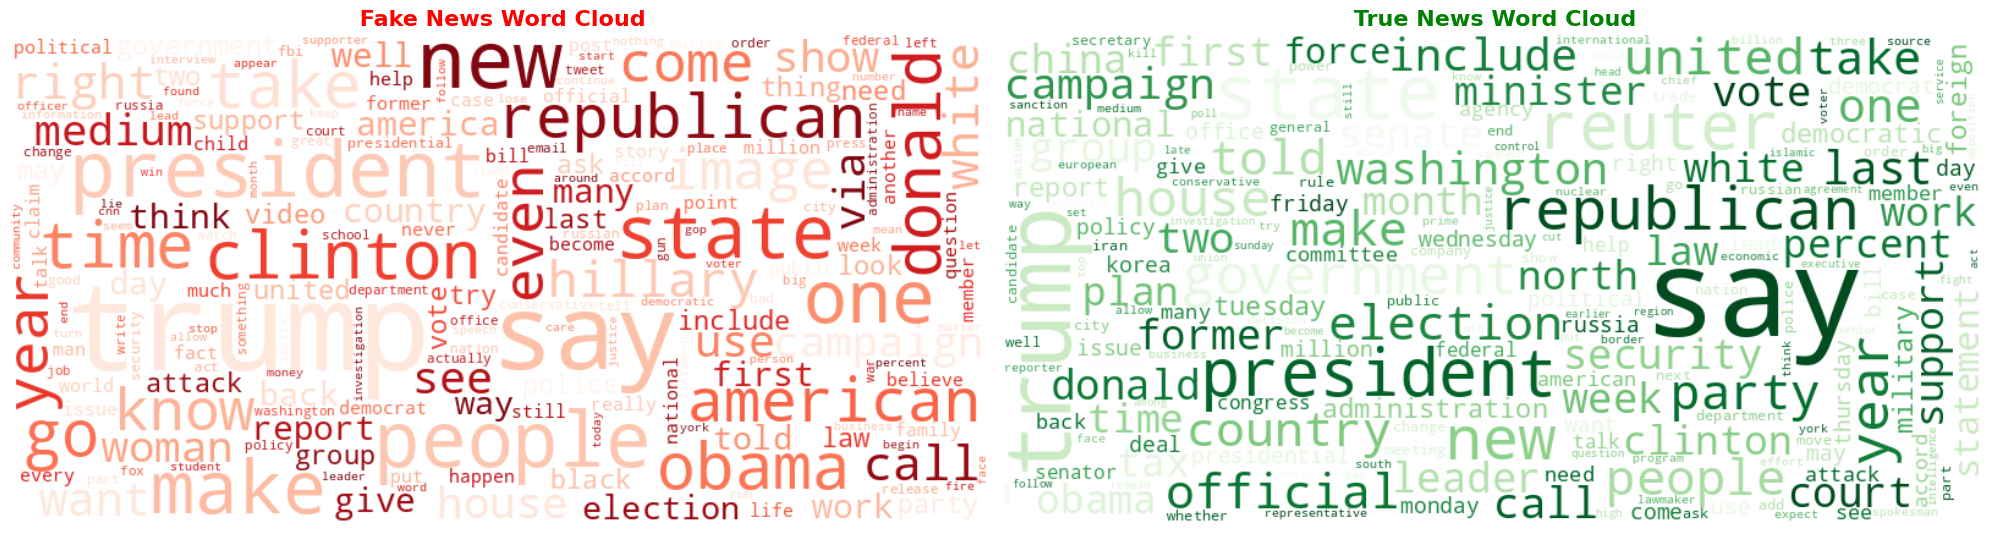

 Word clouds generated successfully!


In [ ]:
!pip install wordcloud -qq # Ensure wordcloud is installed
import matplotlib.pyplot as plt
from wordcloud import WordCloud # Ensure WordCloud is imported here

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Fake news word cloud
fake_text = ' '.join(df[df['class'] == 0]['text'])
fake_wordcloud = WordCloud(
    width=800, height=400,
    max_font_size=100,
    background_color='white',
    colormap='Reds',
    collocations=False
).generate(fake_text)

axes[0].imshow(fake_wordcloud, interpolation='bilinear')
axes[0].set_title(' Fake News Word Cloud', fontsize=16, fontweight='bold', color='red')
axes[0].axis('off')

# True news word cloud
true_text = ' '.join(df[df['class'] == 1]['text'])
true_wordcloud = WordCloud(
    width=800, height=400,
    max_font_size=100,
    background_color='white',
    colormap='Greens',
    collocations=False
).generate(true_text)

axes[1].imshow(true_wordcloud, interpolation='bilinear')
axes[1].set_title(' True News Word Cloud', fontsize=16, fontweight='bold', color='green')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(" Word clouds generated successfully!")

##  GloVe Embeddings Setup & Loading

In [ ]:
# Download GloVe embeddings (this might take a few minutes)
import urllib.request
import zipfile
import os

glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_file = "glove.6B.100d.txt"

if not os.path.exists(glove_file):
    print(" Downloading GloVe embeddings... (this may take a few minutes)")
    try:
        urllib.request.urlretrieve(glove_url, "glove.6B.zip")
        with zipfile.ZipFile("glove.6B.zip", 'r') as zip_ref:
            zip_ref.extract(glove_file)
        os.remove("glove.6B.zip")
        print(" GloVe embeddings downloaded successfully!")
    except Exception as e:
        print(f" Error downloading GloVe: {e}")
        print("Please manually download glove.6B.100d.txt and upload to Colab")
else:
    print("GloVe embeddings already available!")

 GloVe embeddings downloaded successfully!


In [ ]:
def load_glove_embeddings(glove_file):
    """Load GloVe embeddings from file"""
    print(" Loading GloVe embeddings...")
    embeddings_dict = {}

    try:
        with open(glove_file, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                vector = np.asarray(values[1:], dtype='float32')
                embeddings_dict[word] = vector

        print(f" Loaded {len(embeddings_dict)} GloVe word vectors")
        return embeddings_dict

    except FileNotFoundError:
        print(" GloVe file not found. Please ensure glove.6B.100d.txt is available")
        return None

# Define glove_file here to make it accessible
glove_file = "glove.6B.100d.txt"

# Load GloVe embeddings
glove_embeddings = load_glove_embeddings(glove_file)

if glove_embeddings:
    print(f" Embedding dimension: {len(list(glove_embeddings.values())[0])}")
    print(f" Vocabulary size: {len(glove_embeddings)}")

 Loading GloVe embeddings...
 Loaded 400000 GloVe word vectors
 Embedding dimension: 100
 Vocabulary size: 400000


##  Feature Extraction with GloVe

In [ ]:
# ===== Feature Extraction with GloVe (replacement) =====
import numpy as np

# Ensure glove_embeddings dict and glove_file are loaded before this block
# If your manual test df is called df_manual_test, keep it. Otherwise adapt name.

def get_glove_vector(text, embeddings_dict, vector_size=100):
    """Convert text to GloVe mean vector (100-dim)."""
    words = str(text).split()
    vectors = [embeddings_dict[word] for word in words if word in embeddings_dict]
    if len(vectors) == 0:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0)

# Build GloVe matrix for main dataframe
print("Converting texts to GloVe vectors (this may take a while)...")
X = np.vstack([get_glove_vector(t, glove_embeddings) for t in df['text'].astype(str).values])
y = df['class'].values

# If manual test exists (df_manual_test), convert it as well
if 'df_manual_test' in globals():
    X_manual = np.vstack([get_glove_vector(t, glove_embeddings) for t in df_manual_test['text'].astype(str).values])
    y_manual = df_manual_test['class'].values
    print(f"Manual test features shape: {X_manual.shape}")
else:
    X_manual, y_manual = None, None

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


Converting texts to GloVe vectors (this may take a while)...
Manual test features shape: (20, 100)
Feature matrix shape: (44878, 100)
Target vector shape: (44878,)


##  Train-Test Split

In [ ]:
# ===== Train-Test Split (consistent indices) =====
import numpy as np
from sklearn.model_selection import train_test_split

RND = 42
TEST_SIZE = 0.2

# indices split ensures same test set for all representations
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=TEST_SIZE, random_state=RND, stratify=y)

# GloVe train/test using indices
X_train = X[train_idx]
X_test  = X[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

print("Data Split Summary:")
print(f" Training set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")


Data Split Summary:
 Training set: 35902 samples
 Test set: 8976 samples


##  Machine Learning Models Training

TF-IDF features for Naïve Bayes baseline

In [ ]:
# ===== TF-IDF features for Naive Bayes baseline =====
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
X_tfidf_all = tfidf.fit_transform(df['text'].astype(str))   # sparse matrix

# Align train/test using previously computed indices
X_train_tf = X_tfidf_all[train_idx]
X_test_tf  = X_tfidf_all[test_idx]

print("TF-IDF matrix shape:", X_tfidf_all.shape)
print("TF-IDF train/test shapes:", X_train_tf.shape, X_test_tf.shape)


TF-IDF matrix shape: (44878, 10000)
TF-IDF train/test shapes: (35902, 10000) (8976, 10000)


Model training — GloVe models (RandomForest, SVM, KNN, DecisionTree, LogisticRegression)

In [ ]:
# ===== Train GloVe-based models =====
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

models_glove = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RND, n_jobs=-1),
    "SVM": LinearSVC(random_state=RND, max_iter=5000),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=RND),
    "Logistic Regression": LogisticRegression(random_state=RND, max_iter=2000)
}

results = {}
predictions = []  # predictions for ensemble (order preserved)

for name, model in models_glove.items():
    print(f"Training (GloVe) {name}...")
    try:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    except Exception as e:
        print(f"  CV failed for {name}: {e}. Continuing without CV.")
        cv_scores = np.array([np.nan])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions.append(y_pred)
    results[name] = {
        "CV Accuracy": float(np.nanmean(cv_scores)),
        "CV Std": float(np.nanstd(cv_scores)),
        "Test Accuracy": float((y_pred == y_test).mean()),
        "Precision": float(__import__('sklearn.metrics').metrics.precision_score(y_test, y_pred)),
        "Recall": float(__import__('sklearn.metrics').metrics.recall_score(y_test, y_pred)),
        "F1-Score": float(__import__('sklearn.metrics').metrics.f1_score(y_test, y_pred))
    }
    print(f"  Test Accuracy: {results[name]['Test Accuracy']:.4f}")


Training (GloVe) Random Forest...
  Test Accuracy: 0.9414
Training (GloVe) SVM...
  Test Accuracy: 0.9313
Training (GloVe) KNN...
  Test Accuracy: 0.9151
Training (GloVe) Decision Tree...
  Test Accuracy: 0.8924
Training (GloVe) Logistic Regression...
  Test Accuracy: 0.9296


Naïve Bayes baseline (TF-IDF)

In [ ]:
# ===== Naive Bayes on TF-IDF baseline =====
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score

print("Training Naive Bayes (TF-IDF baseline)...")
nb = MultinomialNB()
cv_scores_nb = cross_val_score(nb, X_train_tf, y_train, cv=5, scoring='accuracy', n_jobs=-1)

nb.fit(X_train_tf, y_train)
y_pred_nb = nb.predict(X_test_tf)

predictions.append(y_pred_nb)   # add NB predictions to ensemble
results["Naive Bayes (TF-IDF)"] = {
    "CV Accuracy": float(cv_scores_nb.mean()),
    "CV Std": float(cv_scores_nb.std()),
    "Test Accuracy": float((y_pred_nb == y_test).mean()),
    "Precision": float(__import__('sklearn.metrics').metrics.precision_score(y_test, y_pred_nb)),
    "Recall": float(__import__('sklearn.metrics').metrics.recall_score(y_test, y_pred_nb)),
    "F1-Score": float(__import__('sklearn.metrics').metrics.f1_score(y_test, y_pred_nb))
}
print(f"  NB Test Accuracy: {results['Naive Bayes (TF-IDF)']['Test Accuracy']:.4f}")


Training Naive Bayes (TF-IDF baseline)...
  NB Test Accuracy: 0.9218


##  Ensemble Learning (Hybrid Classifier)

In [ ]:
# ===== Ensemble: majority voting (correct aggregation) =====
import numpy as np
from scipy.stats import mode

# Convert list of prediction arrays (n_models, n_test_samples)
preds_array = np.vstack(predictions)   # shape: (n_models, n_test_samples)
ensemble_mode = mode(preds_array, axis=0).mode.flatten()  # shape: (n_test_samples,)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results["Hybrid Ensemble (majority vote)"] = {
    "Test Accuracy": float(accuracy_score(y_test, ensemble_mode)),
    "Precision": float(precision_score(y_test, ensemble_mode)),
    "Recall": float(recall_score(y_test, ensemble_mode)),
    "F1-Score": float(f1_score(y_test, ensemble_mode))
}

print("Ensemble Test Accuracy:", results["Hybrid Ensemble (majority vote)"]["Test Accuracy"])


Ensemble Test Accuracy: 0.9451871657754011


##  Model Performance Analysis


FINAL RESULTS:
                                 CV Accuracy  CV Std  Test Accuracy  Precision  Recall  F1-Score
Hybrid Ensemble (majority vote)          NaN     NaN         0.9452     0.9573  0.9264    0.9416
Random Forest                         0.9356  0.0024         0.9414     0.9448  0.9316    0.9381
SVM                                   0.9290  0.0031         0.9313     0.9269  0.9292    0.9280
Logistic Regression                   0.9272  0.0030         0.9296     0.9252  0.9274    0.9263
Naive Bayes (TF-IDF)                  0.9225  0.0029         0.9218     0.9288  0.9054    0.9170
KNN                                   0.9166  0.0025         0.9151     0.8897  0.9383    0.9134
Decision Tree                         0.8838  0.0025         0.8924     0.9032  0.8674    0.8849


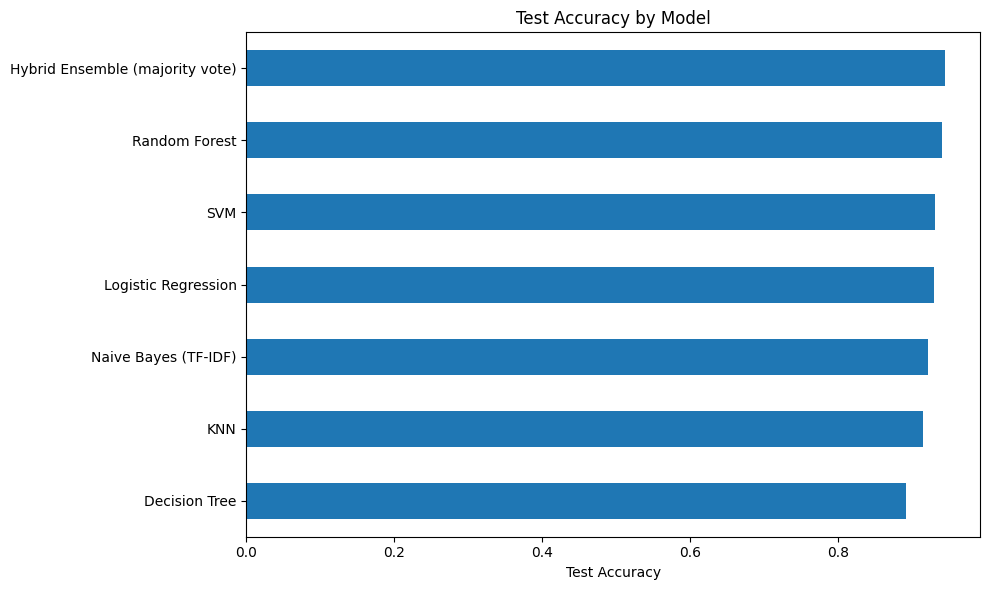

In [ ]:
# ===== Model Performance Summary =====
import pandas as pd
res_df = pd.DataFrame(results).T
res_df = res_df.round(4)
res_df = res_df.sort_values(by="Test Accuracy", ascending=False)

print("\nFINAL RESULTS:")
print(res_df.to_string())

# Optional: quick bar chart for Test Accuracy and F1
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
res_df['Test Accuracy'].plot(kind='barh')
plt.title('Test Accuracy by Model')
plt.xlabel('Test Accuracy')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
if glove_embeddings and results:
    # Create performance visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Test Accuracy comparison
    accuracy_data = results_df['Test Accuracy'].sort_values(ascending=True)
    colors = plt.cm.viridis(np.linspace(0, 1, len(accuracy_data)))
    bars1 = axes[0,0].barh(range(len(accuracy_data)), accuracy_data.values, color=colors)
    axes[0,0].set_yticks(range(len(accuracy_data)))
    axes[0,0].set_yticklabels(accuracy_data.index)
    axes[0,0].set_title(' Test Accuracy Comparison', fontweight='bold', fontsize=14)
    axes[0,0].set_xlabel('Accuracy')

    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars1, accuracy_data.values)):
        axes[0,0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                      f'{val:.3f}', ha='left', va='center', fontweight='bold')

    # 2. F1-Score comparison
    f1_data = results_df['F1-Score'].sort_values(ascending=True)
    bars2 = axes[0,1].barh(range(len(f1_data)), f1_data.values, color=colors)
    axes[0,1].set_yticks(range(len(f1_data)))
    axes[0,1].set_yticklabels(f1_data.index)
    axes[0,1].set_title(' F1-Score Comparison', fontweight='bold', fontsize=14)
    axes[0,1].set_xlabel('F1-Score')

    for i, (bar, val) in enumerate(zip(bars2, f1_data.values)):
        axes[0,1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                      f'{val:.3f}', ha='left', va='center', fontweight='bold')

    # 3. Precision vs Recall scatter plot
    axes[1,0].scatter(results_df['Precision'], results_df['Recall'],
                     s=200, alpha=0.7, c=colors[:len(results_df)])
    axes[1,0].set_xlabel('Precision')
    axes[1,0].set_ylabel('Recall')
    axes[1,0].set_title('Precision vs Recall', fontweight='bold', fontsize=14)

    # Add labels to points
    for i, (name, row) in enumerate(results_df.iterrows()):
        axes[1,0].annotate(name.split()[1] if len(name.split()) > 1 else name,
                          (row['Precision'], row['Recall']),
                          xytext=(5, 5), textcoords='offset points', fontsize=9)

    # 4. Cross-validation accuracy with error bars
    cv_acc = results_df['CV Accuracy']
    cv_std = results_df['CV Std']
    x_pos = range(len(cv_acc))
    bars4 = axes[1,1].bar(x_pos, cv_acc.values, yerr=cv_std.values,
                         capsize=5, color=colors, alpha=0.8)
    axes[1,1].set_xticks(x_pos)
    axes[1,1].set_xticklabels([name.split()[1] if len(name.split()) > 1 else name
                              for name in cv_acc.index], rotation=45)
    axes[1,1].set_title('Cross-Validation Accuracy', fontweight='bold', fontsize=14)
    axes[1,1].set_ylabel('CV Accuracy')

    plt.tight_layout()
    plt.show()

    print(" Performance visualizations completed!")

##  Confusion Matrix Analysis

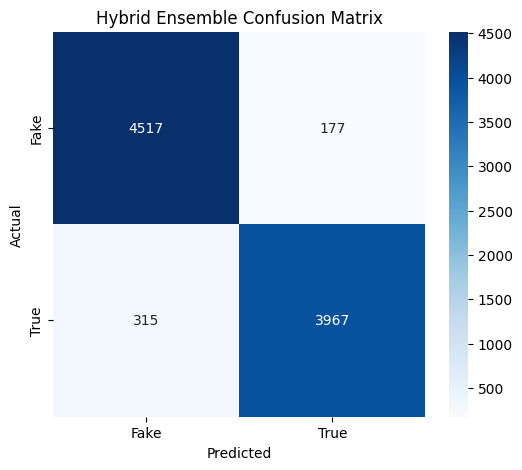

Classification Report - Hybrid Ensemble
              precision    recall  f1-score   support

   Fake News       0.93      0.96      0.95      4694
   True News       0.96      0.93      0.94      4282

    accuracy                           0.95      8976
   macro avg       0.95      0.94      0.94      8976
weighted avg       0.95      0.95      0.95      8976



In [ ]:
# ===== Confusion Matrix & Classification Report for Ensemble =====
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

cm_ensemble = confusion_matrix(y_test, ensemble_mode)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake','True'], yticklabels=['Fake','True'])
plt.title('Hybrid Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report - Hybrid Ensemble")
print(classification_report(y_test, ensemble_mode, target_names=['Fake News','True News']))


##  Sample Testing with Predefined Examples

In [ ]:
# ===== Evaluate on manual test set (if available) =====
if X_manual is not None:
    # Make predictions per-model if you need; here evaluate ensemble by majority of current trained models:
    # Build per-model predictions on manual set:
    manual_preds = []
    # GloVe models (trained earlier in models_glove)
    for name, model in models_glove.items():
        manual_preds.append(model.predict(X_manual))
    # NB on TF-IDF: need to vectorize manual text using tfidf.transform
    X_manual_tf = tfidf.transform(df_manual_test['text'].astype(str))
    manual_preds.append(nb.predict(X_manual_tf))

    manual_preds_array = np.vstack(manual_preds)
    manual_ensemble = mode(manual_preds_array, axis=0).mode.flatten()
    print("Manual test Ensemble accuracy:", (manual_ensemble == y_manual).mean())


Manual test Ensemble accuracy: 1.0
